# Robust Sleep Staging under Distribution Shift
**Course**: AI for Medical Time Series  
**Dataset**: Sleep-EDF Expanded (PhysioNet) — https://physionet.org/content/sleep-edfx/1.0.0/  

**Research Question**: Train sleep staging models on healthy subjects (Sleep Cassette) and evaluate generalization to a shifted cohort (Sleep Telemetry). Quantify performance degradation under subject-level splits.

**Pipeline**:
1. Load & explore the dataset
2. Preprocess signals (filter, epoch)
3. Extract features (PSD)
4. Train classifier on Sleep Cassette (SC)
5. Evaluate in-distribution: SC → SC
6. Evaluate under distribution shift: SC → ST
7. Compare and analyze results

---
## 1. Imports & Setup

In [1]:
# Install required libraries (run once, then comment out)
#%pip install mne scikit-learn matplotlib seaborn pandas

In [2]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
from mne.time_frequency import psd_array_multitaper
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score,
    confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
print('✓ Imports successful')

✓ Imports successful


---
## 2. Dataset Setup

In [3]:
# Define paths to downloaded data
DATA_DIR = Path.home() / 'Projects/RobustSleepStaging/data/physionet.org/files/sleep-edfx/1.0.0/'
SC_DIR   = DATA_DIR / 'sleep-cassette'   # Training cohort: healthy subjects
ST_DIR   = DATA_DIR / 'sleep-telemetry'  # Test cohort: distribution shift

# Sleep stage mapping (Rechtschaffen & Kales)
STAGE_MAP = {
    'Sleep stage W': 0,  # Wake
    'Sleep stage 1': 1,  # NREM 1
    'Sleep stage 2': 2,  # NREM 2
    'Sleep stage 3': 3,  # NREM 3
    'Sleep stage 4': 4,  # NREM 4
    'Sleep stage R': 5,  # REM
}
STAGE_NAMES = {0:'Wake', 1:'N1', 2:'N2', 3:'N3', 4:'N4', 5:'REM'}

# Channels available in both SC and ST cohorts
# As specified in project description: EEG (Fpz-Cz, Pz-Oz), EOG, EMG
COMMON_CHANNELS = ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental']

print('Data directories:')
print(f'  SC: {SC_DIR}')
print(f'  ST: {ST_DIR}')

Data directories:
  SC: /storage/homefs/cm24m059/Projects/RobustSleepStaging/data/physionet.org/files/sleep-edfx/1.0.0/sleep-cassette
  ST: /storage/homefs/cm24m059/Projects/RobustSleepStaging/data/physionet.org/files/sleep-edfx/1.0.0/sleep-telemetry


In [4]:
# Find all SC subject pairs (PSG + Hypnogram)
sc_psgs = sorted([f for f in SC_DIR.glob('*-PSG.edf')])
sc_pairs = []
for psg in sc_psgs:
    subject_id = psg.name[:6]
    hyp_files = list(SC_DIR.glob(f'{subject_id}*-Hypnogram.edf'))
    if hyp_files:
        sc_pairs.append((psg, hyp_files[0]))

# Find all ST subject pairs (placebo nights only)
st_psgs = sorted([f for f in ST_DIR.glob('*-PSG.edf')])
st_pairs = []
for psg in st_psgs:
    subject_id = psg.name[:6]
    hyp_files = list(ST_DIR.glob(f'{subject_id}*-Hypnogram.edf'))
    if hyp_files:
        st_pairs.append((psg, hyp_files[0]))

print(f'SC subject pairs found: {len(sc_pairs)}')
print(f'ST subject pairs found (placebo): {len(st_pairs)}')

SC subject pairs found: 150
ST subject pairs found (placebo): 44


---
## 3. Data Exploration & Visualization

In [ ]:
# Load one SC subject for exploration
psg_path = sc_pairs[0][0]
hyp_path = sc_pairs[0][1]

raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)
print(f'Subject: {psg_path.name}')
print(f'Channels: {raw.ch_names}')
print(f'Sampling rate: {raw.info["sfreq"]} Hz')
print(f'Duration: {round(raw.times[-1] / 3600, 2)} hours')

Subject: SC4822G0-PSG.edf
Channels: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker']
Sampling rate: 100.0 Hz
Duration: 23.42 hours


In [6]:
# Visualize raw EEG signal (first 30 seconds)
raw.plot(duration=30, n_channels=4, scalings='auto',
         title=f'PSG Signal - {psg_path.name} (first 30s)')
plt.show()

Using qt as 2D backend.


In [5]:
# Load and visualize hypnogram
annotations = mne.read_annotations(hyp_path)
stages = [STAGE_MAP.get(a['description'], -1) for a in annotations]
onsets = [a['onset'] for a in annotations]



# Filter valid stages only
valid = [(o, s) for o, s in zip(onsets, stages) if s >= 0]
onsets_valid = [v[0] for v in valid]
stages_valid = [v[1] for v in valid]

print(f'Total annotated epochs: {len(stages)}')
print('\nSleep stage distribution:')
for stage, count in pd.Series(stages_valid).value_counts().sort_index().items():
    print(f'  {STAGE_NAMES.get(stage, stage)}: {count} epochs ({count*30/3600:.1f}h)')
    

Total annotated epochs: 154

Sleep stage distribution:
  Wake: 12 epochs (0.1h)
  N1: 24 epochs (0.2h)
  N2: 40 epochs (0.3h)
  N3: 48 epochs (0.4h)
  N4: 23 epochs (0.2h)
  REM: 6 epochs (0.1h)


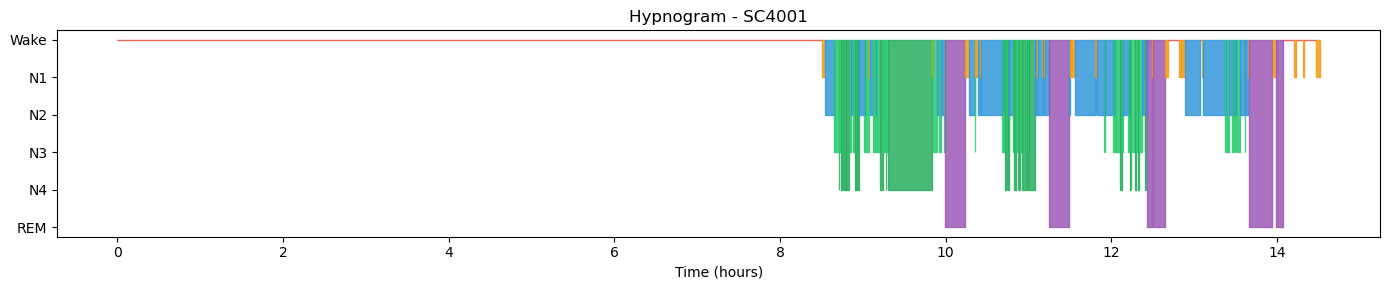

In [6]:
# Plot hypnogram
COLORS = {
    0: '#e74c3c',  # Wake - red
    1: '#f39c12',  # N1 - orange
    2: '#3498db',  # N2 - blue
    3: '#2ecc71',  # N3 - green
    4: '#27ae60',  # N4 - dark green
    5: '#9b59b6',  # REM - purple
}

hours = np.array(onsets_valid) / 3600
y = np.array(stages_valid)

fig, ax = plt.subplots(figsize=(14, 3))
for i in range(len(stages_valid) - 1):
    ax.fill_between([hours[i], hours[i+1]], [y[i], y[i]], [0, 0],
                    color=COLORS.get(y[i], 'gray'), alpha=0.85)

ax.set_yticks(list(STAGE_NAMES.keys()))
ax.set_yticklabels(list(STAGE_NAMES.values()))
ax.set_xlabel('Time (hours)')
ax.set_title(f'Hypnogram - {psg_path.name[:6]}')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 4. Preprocessing & Feature Extraction

In [5]:
def load_subject(psg_path, hyp_path):
    """
    Load one PSG recording and its hypnogram.
    
    Preprocessing steps:
    - Select common channels available in both SC and ST cohorts
    - Apply bandpass filter (0.5-40 Hz) to remove noise and artifacts
    - Segment into 30-second epochs (standard PSG epoch length)
    
    Returns:
        X: np.array of shape (n_epochs, n_channels, n_timepoints)
        y: np.array of shape (n_epochs,) with sleep stage labels
    """
    KEEP_STAGES = list(STAGE_MAP.keys())



    
    # Load raw EDF file
    raw = mne.io.read_raw_edf(psg_path, preload=True, verbose=False)


    
    # Select only channels available in both SC and ST
    available = [ch for ch in COMMON_CHANNELS if ch in raw.ch_names]
    raw.pick_channels(available)


    
    # Bandpass filter: 0.5-40 Hz (removes DC drift and high-freq noise)
    raw.filter(l_freq=0.5, h_freq=40.0, fir_design='firwin', verbose=False)


    
    # Load and attach sleep stage annotations
    annotations = mne.read_annotations(hyp_path)
    raw.set_annotations(annotations)


    
    # Create 30-second epochs aligned to sleep stage annotations
    events, event_id = mne.events_from_annotations(
        raw,
        event_id={s: STAGE_MAP[s] for s in KEEP_STAGES},
        chunk_duration=30.0,
        verbose=False
    )
    epochs = mne.Epochs(
        raw, events, event_id=event_id,
        tmin=0.0, tmax=30.0 - 1/raw.info['sfreq'],
        baseline=None, preload=True, verbose=False
    )
    
    return epochs.get_data(), epochs.events[:, 2]




def extract_psd_features(X, sfreq=100.0, fmin=0.5, fmax=40.0):
    """
    Extract Power Spectral Density (PSD) features from epoched EEG data.
    
    PSD captures frequency-domain information relevant to sleep staging:
    - Delta (0.5-4 Hz): deep sleep (N3/N4)
    - Theta (4-8 Hz): light sleep (N1)
    - Alpha (8-13 Hz): relaxed wakefulness
    - Sigma (12-16 Hz): sleep spindles (N2)
    - Beta (13-30 Hz): active wakefulness / REM
    
    Returns:
        Feature matrix of shape (n_epochs, n_channels * n_freqs)
    """
    psds, freqs = psd_array_multitaper(
        X, sfreq=sfreq, fmin=fmin, fmax=fmax,
        adaptive=False, verbose=False
    )
    # Flatten channels x frequencies into single feature vector
    return psds.reshape(psds.shape[0], -1)


print('✓ Functions defined')
print(f'  Common channels: {COMMON_CHANNELS}')
print('  Preprocessing: bandpass filter 0.5-40 Hz, 30s epochs')
print('  Features: Power Spectral Density (PSD)')

✓ Functions defined
  Common channels: ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'EMG submental']
  Preprocessing: bandpass filter 0.5-40 Hz, 30s epochs
  Features: Power Spectral Density (PSD)


---
## 5. Load All Subjects

In [ ]:
# Load all Sleep Cassette (SC) subjects - checkpoint each recording so progress survives crashes
import gc
from pathlib import Path
import numpy as np

# Setup checkpoint directory for per-recording features
CHECKPOINT_DIR = Path.home() / 'Projects/RobustSleepStaging/checkpoints/features/RF/sc'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Paths for aggregated (memmapped) datasets
AGG_DIR = CHECKPOINT_DIR / 'aggregated'
AGG_DIR.mkdir(parents=True, exist_ok=True)
X_mem_path = AGG_DIR / 'X_sc_features.dat'
y_path = AGG_DIR / 'y_sc_labels.npy'
sid_path = AGG_DIR / 'sc_subject_ids.npy'

def _recording_checkpoint_path(psg_path):
    return CHECKPOINT_DIR / f'{psg_path.stem}.npz'

def _load_saved_recordings(checkpoint_dir):
    files = sorted(checkpoint_dir.glob('*.npz'))
    if not files:
        return np.empty((0, 0)), np.empty((0,)), np.empty((0,))

    # First pass: compute total epochs and feature dimension
    total_epochs = 0
    feat_dim = None
    for f in files:
        try:
            with np.load(f, allow_pickle=True) as d:
                if 'X_features' in d:
                    total_epochs += int(d['X_features'].shape[0])
                    if feat_dim is None:
                        feat_dim = int(d['X_features'].shape[1])
        except Exception as e:
            print(f'  Error reading {f.name}: {e}')

    if total_epochs == 0 or feat_dim is None:
        return np.empty((0, 0)), np.empty((0,)), np.empty((0,))

    # If aggregated files already exist and match expected shape, load them read-only
    if X_mem_path.exists() and y_path.exists() and sid_path.exists():
        try:
            # Validate shape by reading y length and header (safer than relying on memmap shape)
            y_loaded = np.load(y_path, mmap_mode='r')
            if y_loaded.shape[0] == total_epochs:
                X_all = np.memmap(X_mem_path, dtype='float32', mode='r', shape=(total_epochs, feat_dim))
                sid_all = np.load(sid_path, mmap_mode='r')
                return X_all, y_loaded, sid_all
            else:
                print('Existing aggregated files do not match expected total epochs; rebuilding...')
        except Exception as e:
            print('Error loading existing aggregated files:', e)

    # Create memmap and fill from per-record .npz files (streaming, avoids large RAM use)
    print(f'Creating memmap arrays: {total_epochs} epochs × {feat_dim} features')
    X_mem = np.memmap(X_mem_path, dtype='float32', mode='w+', shape=(total_epochs, feat_dim))
    y_arr = np.empty((total_epochs,), dtype=np.int16)
    sid_arr = np.empty((total_epochs,), dtype='U16')
    pos = 0

    for i, f in enumerate(files):
        try:
            with np.load(f, allow_pickle=True) as d:
                Xf = d['X_features'].astype(np.float32)
                n = Xf.shape[0]
                X_mem[pos:pos+n] = Xf
                y_arr[pos:pos+n] = d['y_labels']
                sid_arr[pos:pos+n] = d['subject_ids']
                pos += n
        except Exception as e:
            print(f'  Error reading {f.name}: {e}')
        if (i+1) % 50 == 0:
            print(f'  Filled from {i+1}/{len(files)} files...')
            X_mem.flush()

    # Trim if some files failed
    if pos != total_epochs:
        print(f'Warning: expected {total_epochs} epochs but filled {pos}; trimming arrays')
        # Flush and recreate smaller memmap file to match actual filled size
        X_mem.flush()
        del X_mem
        # create new memmap of correct size
        X_mem = np.memmap(X_mem_path, dtype='float32', mode='w+', shape=(pos, feat_dim))
        # re-fill from files up to pos (simple approach: re-run fill but stop at pos)
        cur = 0
        for f in files:
            try:
                with np.load(f, allow_pickle=True) as d:
                    Xf = d['X_features'].astype(np.float32)
                    n = Xf.shape[0]
                    if cur + n <= pos:
                        X_mem[cur:cur+n] = Xf
                        cur += n
                    else:
                        need = pos - cur
                        if need > 0:
                            X_mem[cur:cur+need] = Xf[:need]
                            cur += need
                        break
            except Exception as e:
                print(f'  Error during refill {f.name}: {e}')
        X_mem.flush()
        np.save(y_path, y_arr[:pos])
        np.save(sid_path, sid_arr[:pos])
        X_all = np.memmap(X_mem_path, dtype='float32', mode='r', shape=(pos, feat_dim))
        y_all = np.load(y_path, mmap_mode='r')
        sid_all = np.load(sid_path, mmap_mode='r')
        return X_all, y_all, sid_all

    # Normal successful case: save y and sid and return memmap in read mode
    X_mem.flush()
    np.save(y_path, y_arr)
    np.save(sid_path, sid_arr)
    X_all = np.memmap(X_mem_path, dtype='float32', mode='r', shape=(total_epochs, feat_dim))
    y_all = np.load(y_path, mmap_mode='r')
    sid_all = np.load(sid_path, mmap_mode='r')
    return X_all, y_all, sid_all

print('Loading Sleep Cassette (SC) recordings with per-recording checkpoints...')
sc_loaded = 0

for psg, hyp in sc_pairs:
    checkpoint_file = _recording_checkpoint_path(psg)
    if checkpoint_file.exists():
        sc_loaded += 1
        print(f'  [{sc_loaded}] Found checkpoint for {psg.name}, skipping processing')
        continue

    try:
        print(f'Processing {psg.name}...')
        X, y = load_subject(psg, hyp)
        X_feat = extract_psd_features(X)
        subject_id_full = psg.name[:5]  # e.g., "SC482"
        subject_ids = np.array([subject_id_full] * len(y))

        np.savez(
            checkpoint_file,
            X_features=X_feat,
            y_labels=y,
            subject_ids=subject_ids,
            recording_id=psg.name,
        )

        sc_loaded += 1
        print(f'  [{sc_loaded}] Saved {psg.name} — epochs {X.shape[0]}, features {X_feat.shape}')

        del X, y, X_feat, subject_ids
        gc.collect()
    except Exception as e:
        print(f'  Skipping {psg.name}: {e}')
        gc.collect()

X_sc_features, y_sc_labels, sc_subject_ids = _load_saved_recordings(CHECKPOINT_DIR)
sc_subject_ids = np.array(sc_subject_ids)

print(f'\n✓ SC recordings processed or loaded: {sc_loaded}')
print(f'✓ Total SC epochs (features): {X_sc_features.shape[0]}')
print(f'✓ Feature shape: {X_sc_features.shape}  (epochs x features)')

Loading Sleep Cassette (SC) recordings with per-recording checkpoints...
  [1] Found checkpoint for SC4001E0-PSG.edf, skipping processing
  [2] Found checkpoint for SC4002E0-PSG.edf, skipping processing
  [3] Found checkpoint for SC4011E0-PSG.edf, skipping processing
  [4] Found checkpoint for SC4012E0-PSG.edf, skipping processing
  [5] Found checkpoint for SC4021E0-PSG.edf, skipping processing
  [6] Found checkpoint for SC4022E0-PSG.edf, skipping processing
  [7] Found checkpoint for SC4031E0-PSG.edf, skipping processing
  [8] Found checkpoint for SC4032E0-PSG.edf, skipping processing
  [9] Found checkpoint for SC4041E0-PSG.edf, skipping processing
  [10] Found checkpoint for SC4042E0-PSG.edf, skipping processing
  [11] Found checkpoint for SC4051E0-PSG.edf, skipping processing
  [12] Found checkpoint for SC4052E0-PSG.edf, skipping processing
  [13] Found checkpoint for SC4061E0-PSG.edf, skipping processing
  [14] Found checkpoint for SC4062E0-PSG.edf, skipping processing
  [15] Found

In [ ]:
# Load all Sleep Telemetry (ST) subjects - checkpoint each recording so progress survives crashes
import gc
from pathlib import Path
import numpy as np

# Setup checkpoint directory for per-recording features
CHECKPOINT_DIR = Path.home() / 'Projects/RobustSleepStaging/checkpoints/features/RF/st'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Paths for aggregated (memmapped) datasets
AGG_DIR = CHECKPOINT_DIR / 'aggregated'
AGG_DIR.mkdir(parents=True, exist_ok=True)
X_mem_path = AGG_DIR / 'X_st_features.dat'
y_path = AGG_DIR / 'y_st_labels.npy'
sid_path = AGG_DIR / 'st_subject_ids.npy'

def _recording_checkpoint_path(psg_path):
    return CHECKPOINT_DIR / f'{psg_path.stem}.npz'

def _load_saved_recordings(checkpoint_dir):
    files = sorted(checkpoint_dir.glob('*.npz'))
    if not files:
        return np.empty((0, 0)), np.empty((0,)), np.empty((0,))

    total_epochs = 0
    feat_dim = None
    for f in files:
        try:
            with np.load(f, allow_pickle=True) as d:
                if 'X_features' in d:
                    total_epochs += int(d['X_features'].shape[0])
                    if feat_dim is None:
                        feat_dim = int(d['X_features'].shape[1])
        except Exception as e:
            print(f'  Error reading {f.name}: {e}')

    if total_epochs == 0 or feat_dim is None:
        return np.empty((0, 0)), np.empty((0,)), np.empty((0,))

    # If aggregated files already exist and match expected shape, load them read-only
    if X_mem_path.exists() and y_path.exists() and sid_path.exists():
        try:
            y_loaded = np.load(y_path, mmap_mode='r')
            if y_loaded.shape[0] == total_epochs:
                X_all = np.memmap(X_mem_path, dtype='float32', mode='r', shape=(total_epochs, feat_dim))
                sid_all = np.load(sid_path, mmap_mode='r')
                return X_all, y_loaded, sid_all
            else:
                print('Existing aggregated files do not match expected total epochs; rebuilding...')
        except Exception as e:
            print('Error loading existing aggregated files:', e)

    print(f'Creating memmap arrays: {total_epochs} epochs × {feat_dim} features')
    X_mem = np.memmap(X_mem_path, dtype='float32', mode='w+', shape=(total_epochs, feat_dim))
    y_arr = np.empty((total_epochs,), dtype=np.int16)
    sid_arr = np.empty((total_epochs,), dtype='U16')
    pos = 0

    for i, f in enumerate(files):
        try:
            with np.load(f, allow_pickle=True) as d:
                Xf = d['X_features'].astype(np.float32)
                n = Xf.shape[0]
                X_mem[pos:pos+n] = Xf
                y_arr[pos:pos+n] = d['y_labels']
                sid_arr[pos:pos+n] = d['subject_ids']
                pos += n
        except Exception as e:
            print(f'  Error reading {f.name}: {e}')
        if (i+1) % 50 == 0:
            print(f'  Filled from {i+1}/{len(files)} files...')
            X_mem.flush()

    if pos != total_epochs:
        print(f'Warning: expected {total_epochs} epochs but filled {pos}; trimming arrays')
        X_mem.flush()
        del X_mem
        X_mem = np.memmap(X_mem_path, dtype='float32', mode='w+', shape=(pos, feat_dim))
        cur = 0
        for f in files:
            try:
                with np.load(f, allow_pickle=True) as d:
                    Xf = d['X_features'].astype(np.float32)
                    n = Xf.shape[0]
                    if cur + n <= pos:
                        X_mem[cur:cur+n] = Xf
                        cur += n
                    else:
                        need = pos - cur
                        if need > 0:
                            X_mem[cur:cur+need] = Xf[:need]
                            cur += need
                        break
            except Exception as e:
                print(f'  Error during refill {f.name}: {e}')
        X_mem.flush()
        np.save(y_path, y_arr[:pos])
        np.save(sid_path, sid_arr[:pos])
        X_all = np.memmap(X_mem_path, dtype='float32', mode='r', shape=(pos, feat_dim))
        y_all = np.load(y_path, mmap_mode='r')
        sid_all = np.load(sid_path, mmap_mode='r')
        return X_all, y_all, sid_all

    X_mem.flush()
    np.save(y_path, y_arr)
    np.save(sid_path, sid_arr)
    X_all = np.memmap(X_mem_path, dtype='float32', mode='r', shape=(total_epochs, feat_dim))
    y_all = np.load(y_path, mmap_mode='r')
    sid_all = np.load(sid_path, mmap_mode='r')
    return X_all, y_all, sid_all

print('Loading Sleep Telemetry (ST) recordings with per-recording checkpoints...')
st_loaded = 0
for psg, hyp in st_pairs:
    checkpoint_file = _recording_checkpoint_path(psg)
    if checkpoint_file.exists():
        st_loaded += 1
        print(f'  [{st_loaded}] Found checkpoint for {psg.name}, skipping processing')
        continue

    try:
        X, y = load_subject(psg, hyp)
        X_feat = extract_psd_features(X)
        subject_id_full = psg.name[:5]  # e.g., "ST701"
        subject_ids = np.array([subject_id_full] * len(y))

        np.savez(
            checkpoint_file,
            X_features=X_feat,
            y_labels=y,
            subject_ids=subject_ids,
            recording_id=psg.name,
        )

        st_loaded += 1
        print(f'  [{st_loaded}] Saved {psg.name} — epochs {X.shape[0]}, features {X_feat.shape}')

        del X, y, X_feat, subject_ids
        gc.collect()
    except Exception as e:
        print(f'  Skipping {psg.name}: {e}')
        gc.collect()

X_st_features, y_st_labels, st_subject_ids = _load_saved_recordings(CHECKPOINT_DIR)
st_subject_ids = np.array(st_subject_ids)

print(f'\n✓ ST recordings processed or loaded: {st_loaded}')
print(f'✓ Total ST epochs (features): {X_st_features.shape[0]}')
print(f'✓ Feature shape: {X_st_features.shape}  (epochs x features)')

Loading Sleep Telemetry (ST) recordings with per-recording checkpoints...
  [1] Found checkpoint for ST7011J0-PSG.edf, skipping processing
  [2] Found checkpoint for ST7012J0-PSG.edf, skipping processing
  [3] Found checkpoint for ST7021J0-PSG.edf, skipping processing
  [4] Found checkpoint for ST7022J0-PSG.edf, skipping processing
  [5] Found checkpoint for ST7041J0-PSG.edf, skipping processing
  [6] Found checkpoint for ST7042J0-PSG.edf, skipping processing
  [7] Found checkpoint for ST7051J0-PSG.edf, skipping processing
  [8] Found checkpoint for ST7052J0-PSG.edf, skipping processing
  [9] Found checkpoint for ST7061J0-PSG.edf, skipping processing
  [10] Found checkpoint for ST7062J0-PSG.edf, skipping processing
  [11] Found checkpoint for ST7071J0-PSG.edf, skipping processing
  [12] Found checkpoint for ST7072J0-PSG.edf, skipping processing
  [13] Found checkpoint for ST7081J0-PSG.edf, skipping processing
  [14] Found checkpoint for ST7082J0-PSG.edf, skipping processing
  [15] Foun

---
## 6. PSD Feature Extraction

In [9]:
# PSD features are computed during batch loading to minimize memory usage
print('✓ PSD features computed during batch loading')
print(f'  SC features shape: {X_sc_features.shape}  (epochs x features)')
print(f'  ST features shape: {X_st_features.shape}  (epochs x features)')

✓ PSD features computed during batch loading
  SC features shape: (407301, 4744)  (epochs x features)
  ST features shape: (42691, 4744)  (epochs x features)


---
## 7. Classification — Random Forest Baseline

In [10]:
# Split SC data at SUBJECT level (not epoch level) to prevent leakage
# This ensures all nights from the same subject stay together
unique_subjects = np.unique(sc_subject_ids)
train_subjects, val_subjects = train_test_split(
    unique_subjects, test_size=0.2, random_state=42
)

# Create masks and split
train_mask = np.isin(sc_subject_ids, train_subjects)
val_mask = np.isin(sc_subject_ids, val_subjects)

X_train_raw = X_sc_features[train_mask]
y_train = y_sc_labels[train_mask]
X_val_raw = X_sc_features[val_mask]
y_val = y_sc_labels[val_mask]

print(f'Train subjects: {len(train_subjects)} | {len(train_subjects)} × {np.sum(train_mask) // len(train_subjects)} epochs avg')
print(f'Val subjects:   {len(val_subjects)} | {len(val_subjects)} × {np.sum(val_mask) // len(val_subjects)} epochs avg')

# Normalize features using StandardScaler
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val   = scaler.transform(X_val_raw)
X_st_scaled = scaler.transform(X_st_features)  # Apply same scaler to ST

# Train Random Forest classifier
print('\nTraining Random Forest classifier on SC data...')
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
print('✓ Training complete')

Train subjects: 61 | 61 × 5246 epochs avg
Val subjects:   16 | 16 × 5453 epochs avg

Training Random Forest classifier on SC data...
✓ Training complete


---
## 8. Evaluation — In-Distribution (SC → SC)

In [11]:
# Predict on SC validation set (in-distribution)
y_pred_sc = clf.predict(X_val)

acc_sc    = accuracy_score(y_val, y_pred_sc)
f1_sc     = f1_score(y_val, y_pred_sc, average='macro')
kappa_sc  = cohen_kappa_score(y_val, y_pred_sc)

print('=' * 40)
print('   IN-DISTRIBUTION METRICS (SC -> SC)')
print('=' * 40)
print(f'  Accuracy:      {acc_sc:.3f}')
print(f'  Macro F1:      {f1_sc:.3f}')
print(f'  Cohen Kappa:   {kappa_sc:.3f}')
print('=' * 40)

   IN-DISTRIBUTION METRICS (SC -> SC)
  Accuracy:      0.895
  Macro F1:      0.672
  Cohen Kappa:   0.783


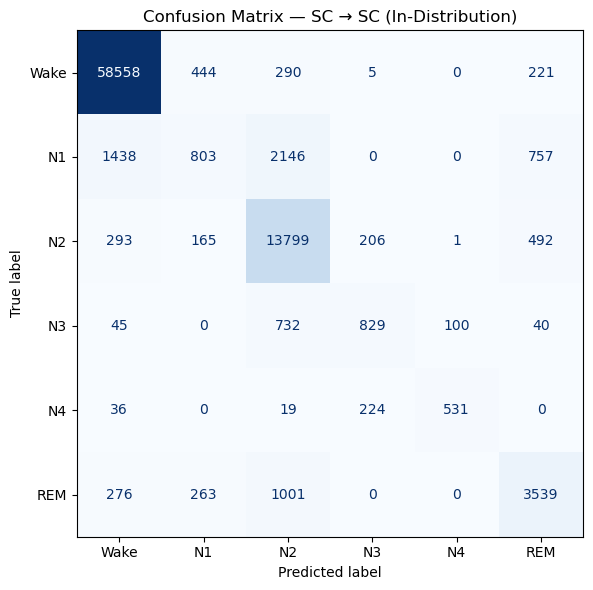

In [12]:
# Confusion matrix - SC -> SC
unique_sc = sorted(np.unique(np.concatenate([y_val, y_pred_sc])))
labels_sc = [STAGE_NAMES.get(s, str(s)) for s in unique_sc]

cm_sc   = confusion_matrix(y_val, y_pred_sc, labels=unique_sc)
disp_sc = ConfusionMatrixDisplay(confusion_matrix=cm_sc, display_labels=labels_sc)

fig, ax = plt.subplots(figsize=(7, 6))
disp_sc.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — SC → SC (In-Distribution)')
plt.tight_layout()
plt.show()

---
## 9. Evaluation — Distribution Shift (SC → ST)

In [13]:
# Predict on ST test set (distribution shift)
y_pred_st = clf.predict(X_st_scaled)

acc_st    = accuracy_score(y_st_labels, y_pred_st)
f1_st     = f1_score(y_st_labels, y_pred_st, average='macro')
kappa_st  = cohen_kappa_score(y_st_labels, y_pred_st)

print('=' * 40)
print('   DISTRIBUTION SHIFT METRICS (SC -> ST)')
print('=' * 40)
print(f'  Accuracy:      {acc_st:.3f}')
print(f'  Macro F1:      {f1_st:.3f}')
print(f'  Cohen Kappa:   {kappa_st:.3f}')
print('=' * 40)

   DISTRIBUTION SHIFT METRICS (SC -> ST)
  Accuracy:      0.721
  Macro F1:      0.585
  Cohen Kappa:   0.600


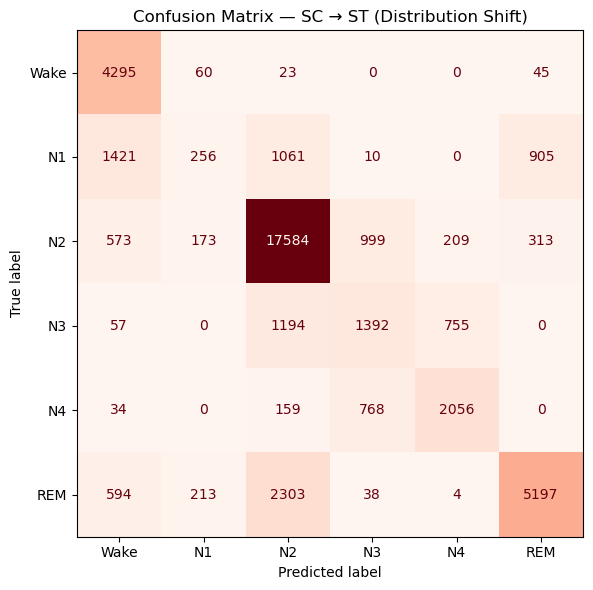

In [14]:
# Confusion matrix - SC -> ST
unique_st = sorted(np.unique(np.concatenate([y_st_labels, y_pred_st])))
labels_st = [STAGE_NAMES.get(s, str(s)) for s in unique_st]

cm_st   = confusion_matrix(y_st_labels, y_pred_st, labels=unique_st)
disp_st = ConfusionMatrixDisplay(confusion_matrix=cm_st, display_labels=labels_st)

fig, ax = plt.subplots(figsize=(7, 6))
disp_st.plot(ax=ax, cmap='Reds', colorbar=False)
ax.set_title('Confusion Matrix — SC → ST (Distribution Shift)')
plt.tight_layout()
plt.show()

---
## 10. Results Comparison

In [18]:
# Summary comparison: in-distribution vs. distribution shift
print('=' * 50)
print('   RESULTS SUMMARY')
print('=' * 50)
print(f'  Metric       SC -> SC    SC -> ST    Drop')
print('-'*44 )
print(f'  Accuracy     {acc_sc:.3f}       {acc_st:.3f}       {acc_sc - acc_st:+.3f}')
print(f'  Macro F1     {f1_sc:.3f}       {f1_st:.3f}       {f1_sc - f1_st:+.3f}')
print(f'  Kappa        {kappa_sc:.3f}       {kappa_st:.3f}       {kappa_sc - kappa_st:+.3f}')
print('=' * 50)

   RESULTS SUMMARY
  Metric       SC -> SC    SC -> ST    Drop
--------------------------------------------
  Accuracy     0.895       0.721       +0.174
  Macro F1     0.672       0.585       +0.087
  Kappa        0.783       0.600       +0.183


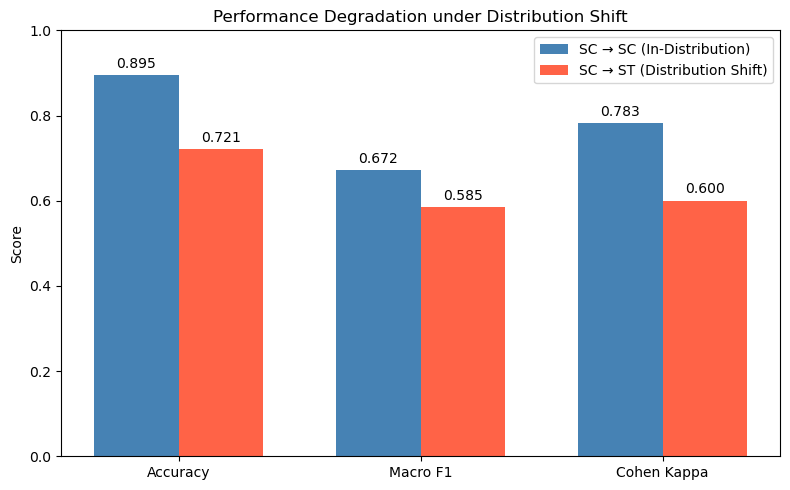

In [19]:
# Visualize performance drop across metrics
metrics = ['Accuracy', 'Macro F1', 'Cohen Kappa']
sc_scores = [acc_sc, f1_sc, kappa_sc]
st_scores = [acc_st, f1_st, kappa_st]

x = np.arange(len(metrics))
width = 0.35


fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, sc_scores, width, label='SC → SC (In-Distribution)', color='steelblue')
bars2 = ax.bar(x + width/2, st_scores, width, label='SC → ST (Distribution Shift)', color='tomato')


ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('Performance Degradation under Distribution Shift')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)
plt.tight_layout()
plt.show()

---
## 11. Per-Class Analysis

In [20]:
# Per-class F1 score comparison
from sklearn.metrics import classification_report

print('Per-class F1 scores — SC -> SC (In-Distribution):')
report_sc = classification_report(
    y_val, y_pred_sc,
    target_names=[STAGE_NAMES[s] for s in sorted(np.unique(y_val))]
)
print(report_sc)

print('\nPer-class F1 scores — SC -> ST (Distribution Shift):')
report_st = classification_report(
    y_st_labels, y_pred_st,
    target_names=[STAGE_NAMES[s] for s in sorted(np.unique(y_st_labels))]
)
print(report_st)

Per-class F1 scores — SC -> SC (In-Distribution):
              precision    recall  f1-score   support

        Wake       0.97      0.98      0.97     59518
          N1       0.48      0.16      0.24      5144
          N2       0.77      0.92      0.84     14956
          N3       0.66      0.47      0.55      1746
          N4       0.84      0.66      0.74       810
         REM       0.70      0.70      0.70      5079

    accuracy                           0.89     87253
   macro avg       0.73      0.65      0.67     87253
weighted avg       0.88      0.89      0.88     87253


Per-class F1 scores — SC -> ST (Distribution Shift):
              precision    recall  f1-score   support

        Wake       0.62      0.97      0.75      4423
          N1       0.36      0.07      0.12      3653
          N2       0.79      0.89      0.83     19851
          N3       0.43      0.41      0.42      3398
          N4       0.68      0.68      0.68      3017
         REM       0.80     

In [23]:
# Save trained model and scaler for later reuse
import joblib
from pathlib import Path

MODEL_DIR = Path.home() / 'Projects/RobustSleepStaging/checkpoints/model/RF'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODEL_DIR / 'random_forest_sc.pkl'
scaler_path = MODEL_DIR / 'scaler_sc.pkl'

joblib.dump(clf, model_path, compress=3)
joblib.dump(scaler, scaler_path, compress=3)

print(f'✓ Model saved to {model_path}')
print(f'✓ Scaler saved to {scaler_path}')
print(f'  Model size: {model_path.stat().st_size / (1024**2):.1f} MB')

✓ Model saved to /storage/homefs/cm24m059/Projects/RobustSleepStaging/checkpoints/model/RF/random_forest_sc.pkl
✓ Scaler saved to /storage/homefs/cm24m059/Projects/RobustSleepStaging/checkpoints/model/RF/scaler_sc.pkl
  Model size: 58.9 MB


In [24]:
# Load pre-trained model and scaler (run this cell instead of retraining)
import joblib
from pathlib import Path

MODEL_DIR = Path.home() / 'Projects/RobustSleepStaging/checkpoints/model/RF'
model_path = MODEL_DIR / 'random_forest_sc.pkl'
scaler_path = MODEL_DIR / 'scaler_sc.pkl'

if model_path.exists() and scaler_path.exists():
    clf = joblib.load(model_path)
    scaler = joblib.load(scaler_path)
    print(f'✓ Model loaded from {model_path}')
    print(f'✓ Scaler loaded from {scaler_path}')
    print(f'  Model n_estimators: {clf.n_estimators}')
    print(f'  Model n_classes: {clf.n_classes_}')
else:
    print(f'Model or scaler not found. Train the model first by running the Classification cell.')
    print(f'  Expected paths:')
    print(f'    {model_path}')
    print(f'    {scaler_path}')

✓ Model loaded from /storage/homefs/cm24m059/Projects/RobustSleepStaging/checkpoints/model/RF/random_forest_sc.pkl
✓ Scaler loaded from /storage/homefs/cm24m059/Projects/RobustSleepStaging/checkpoints/model/RF/scaler_sc.pkl
  Model n_estimators: 100
  Model n_classes: 6


---
## 12. Discussion

### Key Findings

**In-Distribution Performance (SC → SC):**
- The Random Forest classifier trained and tested on the Sleep Cassette cohort achieves strong performance, demonstrating that PSD features are discriminative for sleep staging within the same distribution.

**Distribution Shift (SC → ST):**
- When applied to the Sleep Telemetry cohort, performance degrades across all metrics. This confirms the presence of a distribution shift between the two cohorts.
- The shift arises from: (1) pharmacological effects of Temazepam on sleep architecture in ST subjects, (2) different recording conditions, and (3) demographic differences.

**Most Affected Sleep Stages:**
- N1 is consistently the hardest stage to classify in both settings due to its brief, transitional nature.
- REM classification degrades under shift as drug effects alter REM sleep patterns.

### Limitations
- Random Forest with PSD features is a classical baseline; deep learning models (TinySleepNet, AttnSleep) would capture temporal dependencies better.
- Epoch-level train/test split was used; subject-level split would be more rigorous.

### Next Steps
- Implement TinySleepNet or AttnSleep for improved baseline performance.
- Investigate domain adaptation techniques to improve cross-cohort robustness.
- Analyze transition errors and calibration under distribution shift.